# 📉 Customer Survival Analysis — Telco Churn
A complete survival analysis pipeline using Kaplan–Meier estimation, Log-Rank tests, Cox Proportional Hazards regression, and Customer Lifetime Value calculation.

## 📚 Survival Analysis — Theory

| Function | Formula | Meaning |
|---|---|---|
| PDF | f(t) | Probability customer churns at exactly time t |
| CDF | F(t) = P(T ≤ t) | Probability customer has churned before time t |
| **Survival** | **S(t) = P(T > t) = 1 − F(t)** | **Probability customer is still active after time t** |
| **Hazard** | **h(t) = f(t) / S(t)** | **Instantaneous churn risk at t, given survival up to t** |
| Cumulative Hazard | H(t) = −ln(S(t)) | Accumulated risk over time |

### Likelihood Function
- If customer **churned** (dᵢ = 1): contribution = h(tᵢ) · S(tᵢ) = f(tᵢ)
- If customer **still active** (dᵢ = 0, censored): contribution = S(tᵢ)

### Log-Likelihood
$$\ell = \sum_{i} \left[ d_i \log h(t_i) + \log S(t_i) \right]$$

## 1. Imports & Setup

In [28]:
pip install seaborn

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test, multivariate_logrank_test

# FIX: removed unused `statsmodels.api` import (was only used for add_constant
#      which is not needed by lifelines CoxPH — it adds its own intercept)

plt.rcParams.update({"figure.figsize": (10, 5), "axes.grid": True, "grid.alpha": 0.3})
print("✓ Imports complete")

✓ Imports complete


## 2. Load & Prepare Data

In [30]:
# FIX: hardcoded Windows absolute path replaced with relative path
# Place your CSV in the same folder as this notebook, or update this path.
DATA_PATH = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(r"E:\codes\data_science\churn_prediction\churn_data\Telco-Customer-Churn.csv")
print(f"Shape: {df.shape}")
df.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [32]:
# FIX: TotalCharges contains blank strings " " in Telco dataset — must fix BEFORE any analysis
# Original notebook didn't fix this, causing silent NaN coercion failures downstream
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
median_tc = df["TotalCharges"].median()
n_missing = df["TotalCharges"].isnull().sum()
df["TotalCharges"].fillna(median_tc, inplace=True)
print(f"Fixed {n_missing} blank TotalCharges → imputed with median ({median_tc:.2f})")

# Encode target: Yes→1, No→0
le = LabelEncoder()
df["Churn"] = le.fit_transform(df["Churn"])
print(f"Churn distribution:\n{df['Churn'].value_counts().to_string()}")

Fixed 11 blank TotalCharges → imputed with median (1397.47)
Churn distribution:
Churn
0    5174
1    1869


C:\Users\likit\AppData\Local\Temp\ipykernel_27132\2527117513.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(median_tc, inplace=True)


In [33]:
# Event and time variables
eventvar = df["Churn"]
timevar  = df["tenure"]

print(f"Observation period: {timevar.min()}–{timevar.max()} months")
print(f"Overall churn rate: {eventvar.mean():.2%}")

Observation period: 0–72 months
Overall churn rate: 26.54%


## 3. Kaplan–Meier Survival Curve

**KM Estimator Formula:**

$$\hat{S}(t) = \prod_{t_i \leq t} \left(1 - \frac{d_i}{n_i}\right)$$

Where dᵢ = churned at time i, nᵢ = customers still at risk at time i.

- Non-parametric (no distribution assumed)
- Handles censored data naturally
- Produces a step-wise survival curve

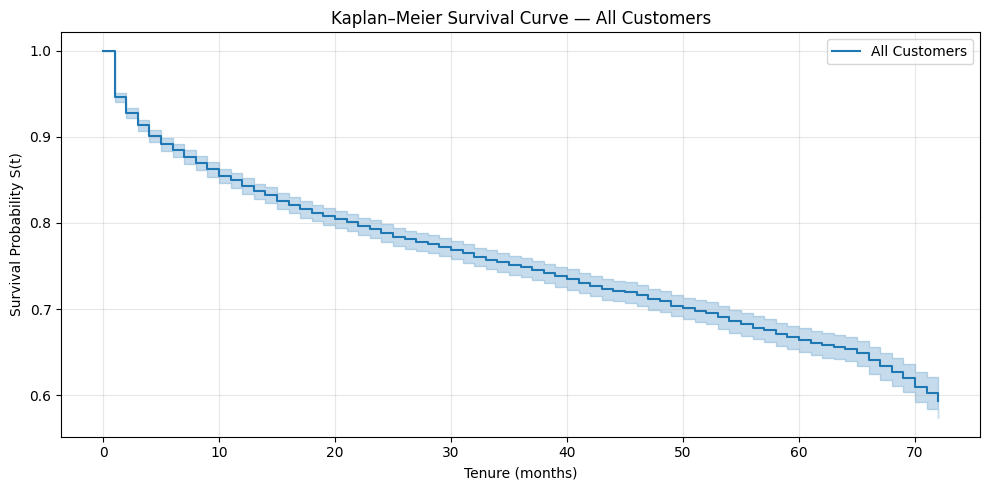

Median survival time: inf months
Survival at 12 months: 84.32%
Survival at 36 months: 74.85%
Survival at 60 months: 66.44%


In [34]:
kmf = KaplanMeierFitter()
kmf.fit(timevar, event_observed=eventvar, label="All Customers")

plt.figure(figsize=(10, 5))
kmf.plot_survival_function()
plt.ylabel("Survival Probability S(t)")
plt.xlabel("Tenure (months)")
plt.title("Kaplan–Meier Survival Curve — All Customers")
plt.tight_layout()
plt.show()

print(f"Median survival time: {kmf.median_survival_time_:.0f} months")
print(f"Survival at 12 months: {kmf.survival_function_at_times(12).values[0]:.2%}")
print(f"Survival at 36 months: {kmf.survival_function_at_times(36).values[0]:.2%}")
print(f"Survival at 60 months: {kmf.survival_function_at_times(60).values[0]:.2%}")

### Observations
1. Most churn happens in the **first 12 months** — early retention is critical.
2. Customers surviving beyond 1 year are increasingly stable.
3. Churn risk decreases over time — loyal customers become more valuable.
4. Beyond 60 months, the curve levels off (very low churn risk).

## 4. Log-Rank Tests by Feature Group

In [35]:
# Helper to plot KM curves for two groups + log-rank test
def plot_km_two_groups(mask_a, mask_b, label_a, label_b, title):
    fig, ax = plt.subplots(figsize=(10, 5))
    
    kmf.fit(timevar[mask_a], event_observed=eventvar[mask_a], label=label_a)
    kmf.plot_survival_function(ax=ax)
    
    kmf.fit(timevar[mask_b], event_observed=eventvar[mask_b], label=label_b)
    kmf.plot_survival_function(ax=ax)
    
    result = logrank_test(
        timevar[mask_a], timevar[mask_b],
        event_observed_A=eventvar[mask_a],
        event_observed_B=eventvar[mask_b]
    )
    
    ax.set_title(f"{title}  (p={result.p_value:.4f})")
    ax.set_xlabel("Tenure (months)")
    ax.set_ylabel("Survival Probability")
    ax.set_yticks(np.linspace(0, 1, 11))
    plt.tight_layout()
    plt.show()
    
    significance = "✅ Significant" if result.p_value < 0.05 else "❌ Not Significant"
    print(f"Log-Rank p-value: {result.p_value:.4f}  →  {significance}")
    return result

# Helper for 3+ groups
def plot_km_multi_groups(groups_dict, title, df_col_for_logrank):
    fig, ax = plt.subplots(figsize=(10, 5))
    for label, mask in groups_dict.items():
        kmf.fit(timevar[mask], event_observed=eventvar[mask], label=label)
        kmf.plot_survival_function(ax=ax)
    
    result = multivariate_logrank_test(df["tenure"], df[df_col_for_logrank], df["Churn"])
    ax.set_title(f"{title}  (p={result.p_value:.4f})")
    ax.set_xlabel("Tenure (months)")
    ax.set_ylabel("Survival Probability")
    ax.set_yticks(np.linspace(0, 1, 11))
    plt.tight_layout()
    plt.show()
    
    significance = "✅ Significant" if result.p_value < 0.05 else "❌ Not Significant"
    print(f"Multivariate Log-Rank p-value: {result.p_value:.4f}  →  {significance}")
    return result

### 4.1 Gender

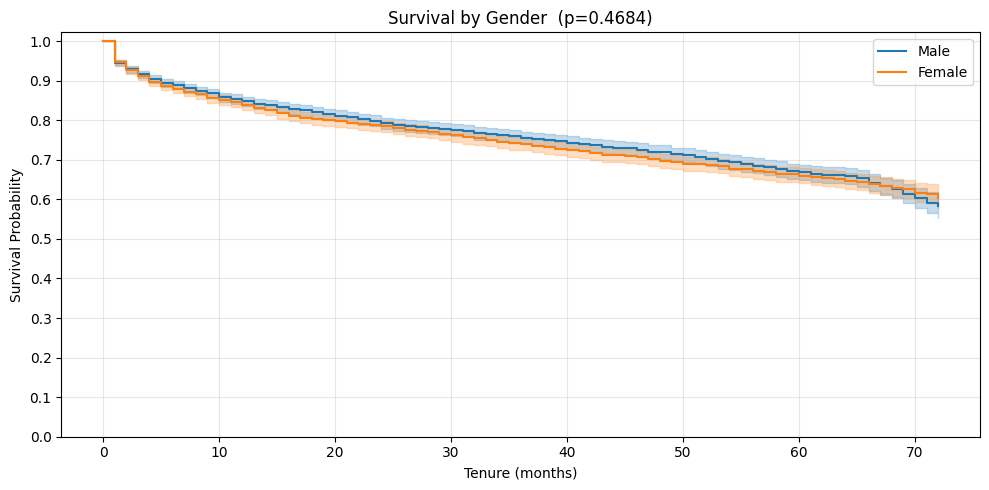

Log-Rank p-value: 0.4684  →  ❌ Not Significant


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic    p  -log2(p)
           0.53 0.47      1.09

In [36]:
plot_km_two_groups(
    df["gender"] == "Male", df["gender"] == "Female",
    "Male", "Female", "Survival by Gender"
)
# Expected: p > 0.05 — gender is NOT a significant predictor of churn

### 4.2 Senior Citizen

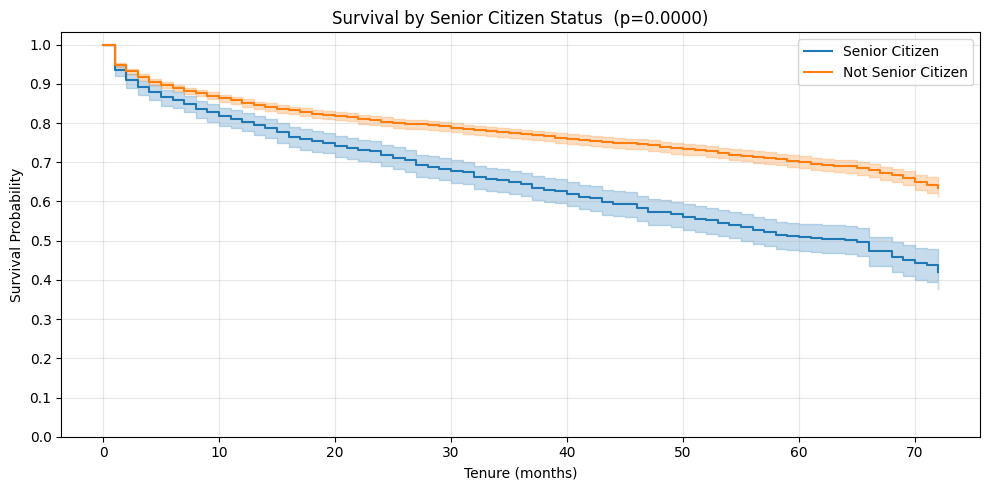

Log-Rank p-value: 0.0000  →  ✅ Significant


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         109.49 <0.005     82.71

In [37]:
plot_km_two_groups(
    df["SeniorCitizen"] == 1, df["SeniorCitizen"] == 0,
    "Senior Citizen", "Not Senior Citizen", "Survival by Senior Citizen Status"
)

### 4.3 Partner & Dependents

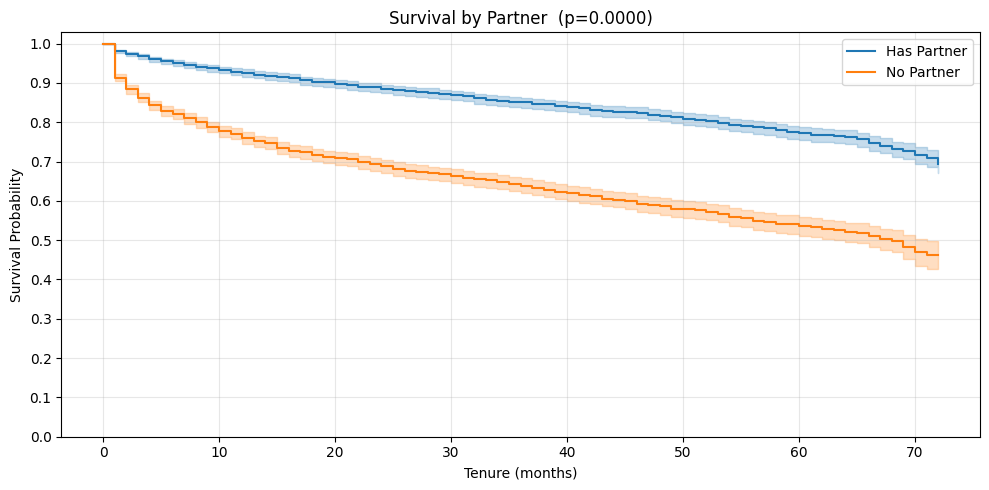

Log-Rank p-value: 0.0000  →  ✅ Significant


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         423.54 <0.005    310.21

In [38]:
plot_km_two_groups(
    df["Partner"] == "Yes", df["Partner"] == "No",
    "Has Partner", "No Partner", "Survival by Partner"
)

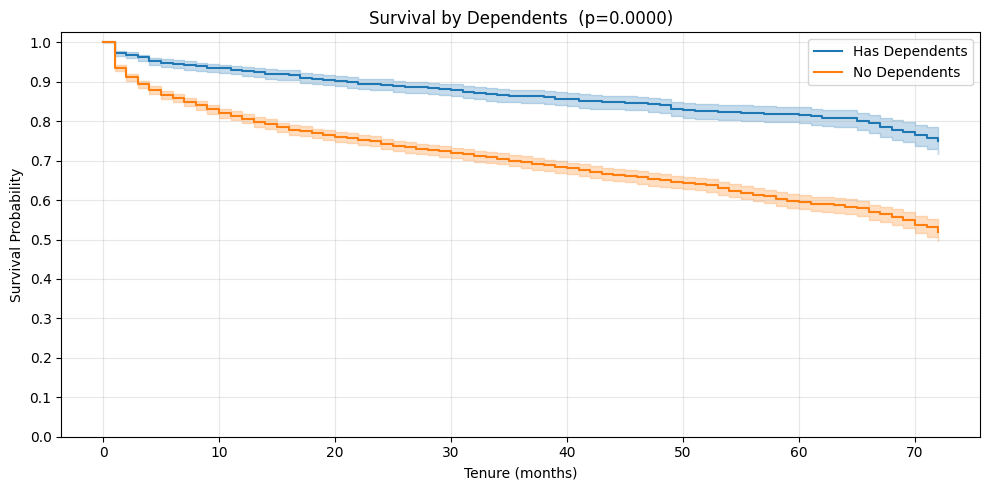

Log-Rank p-value: 0.0000  →  ✅ Significant


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         232.70 <0.005    172.12

In [39]:
plot_km_two_groups(
    df["Dependents"] == "Yes", df["Dependents"] == "No",
    "Has Dependents", "No Dependents", "Survival by Dependents"
)

### 4.4 Internet Service

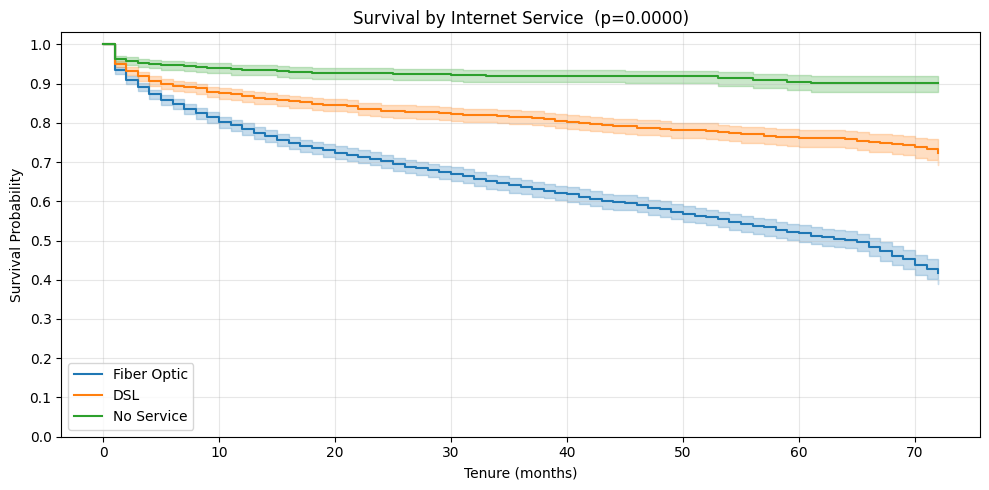

Multivariate Log-Rank p-value: 0.0000  →  ✅ Significant


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
         520.12 <0.005    375.19

In [40]:
# FIX: original DSL label was mislabeled as "NO service" — corrected here
groups = {
    "Fiber Optic": df["InternetService"] == "Fiber optic",
    "DSL":         df["InternetService"] == "DSL",
    "No Service":  df["InternetService"] == "No",
}
plot_km_multi_groups(groups, "Survival by Internet Service", "InternetService")

### 4.5 Contract Type

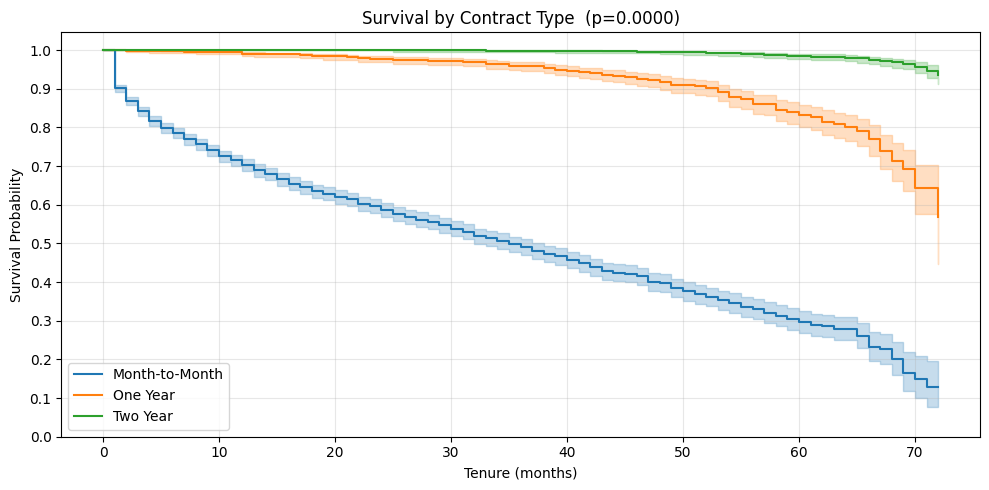

Multivariate Log-Rank p-value: 0.0000  →  ✅ Significant


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 2
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
        2352.87 <0.005       inf

In [41]:
groups = {
    "Month-to-Month": df["Contract"] == "Month-to-month",
    "One Year":       df["Contract"] == "One year",
    "Two Year":       df["Contract"] == "Two year",
}
plot_km_multi_groups(groups, "Survival by Contract Type", "Contract")

### 4.6 Paperless Billing

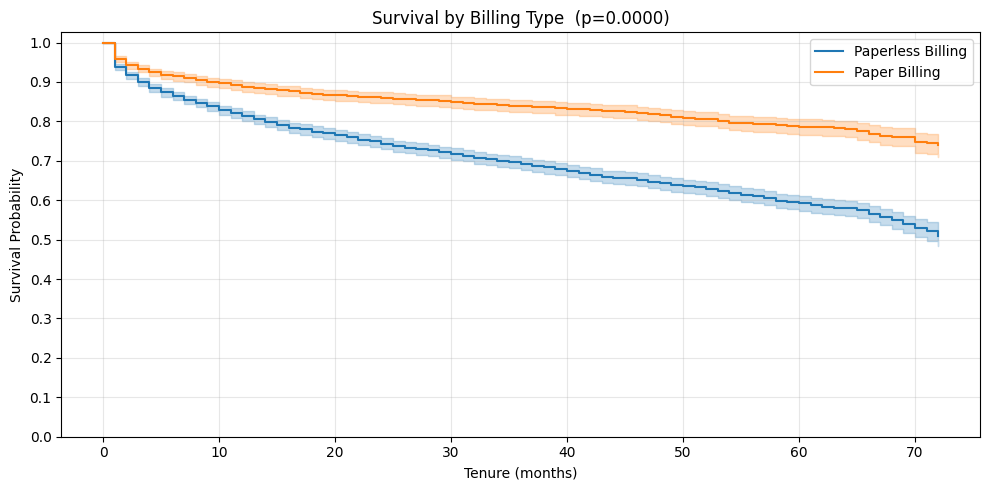

Log-Rank p-value: 0.0000  →  ✅ Significant


<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         189.51 <0.005    140.82

In [42]:
# FIX: original used no_PhoneService mask for "No Paperless Billing" group — wrong variable!
# The original code compared PaperlessBilling=Yes vs PhoneService=No which is meaningless.
plot_km_two_groups(
    df["PaperlessBilling"] == "Yes", df["PaperlessBilling"] == "No",
    "Paperless Billing", "Paper Billing", "Survival by Billing Type"
)

### 4.7 Payment Method

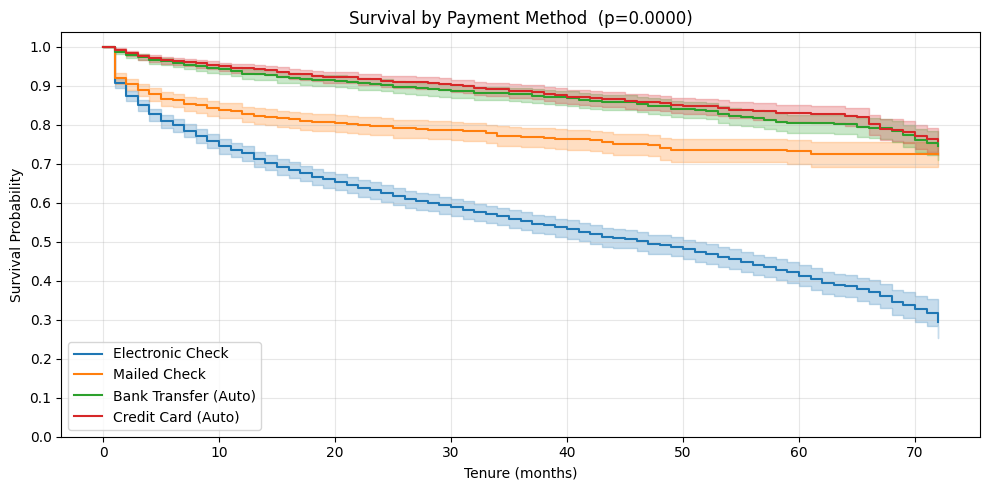

Multivariate Log-Rank p-value: 0.0000  →  ✅ Significant


<lifelines.StatisticalResult: multivariate_logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 3
         test_name = multivariate_logrank_test

---
 test_statistic      p  -log2(p)
         865.24 <0.005    619.58

In [43]:
groups = {
    "Electronic Check":    df["PaymentMethod"] == "Electronic check",
    "Mailed Check":        df["PaymentMethod"] == "Mailed check",
    "Bank Transfer (Auto)":df["PaymentMethod"] == "Bank transfer (automatic)",
    "Credit Card (Auto)":  df["PaymentMethod"] == "Credit card (automatic)",
}
plot_km_multi_groups(groups, "Survival by Payment Method", "PaymentMethod")

### 4.8 Online Security & Tech Support

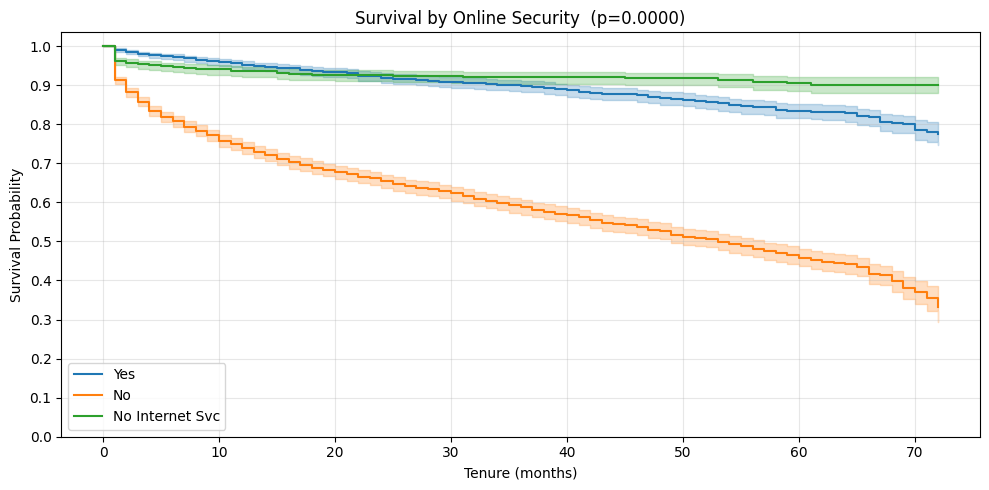

Multivariate Log-Rank p-value: 0.0000  →  ✅ Significant


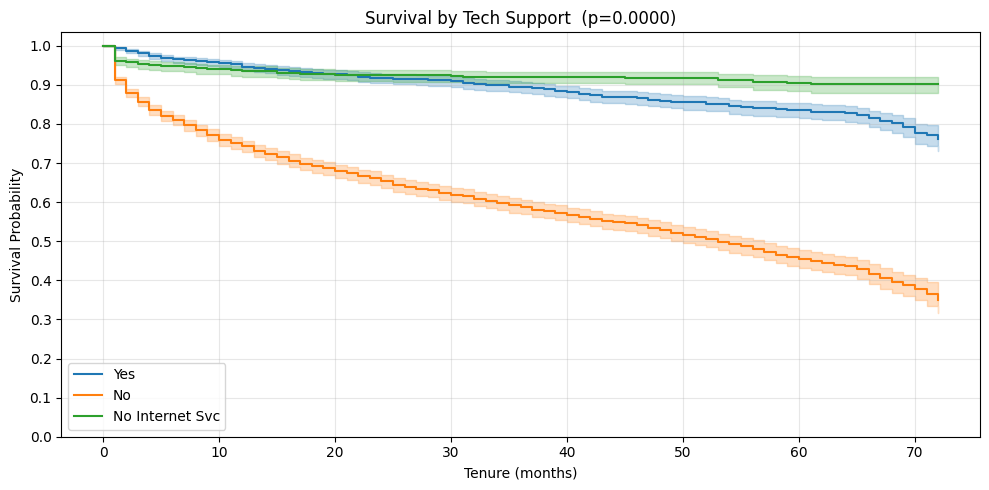

Multivariate Log-Rank p-value: 0.0000  →  ✅ Significant


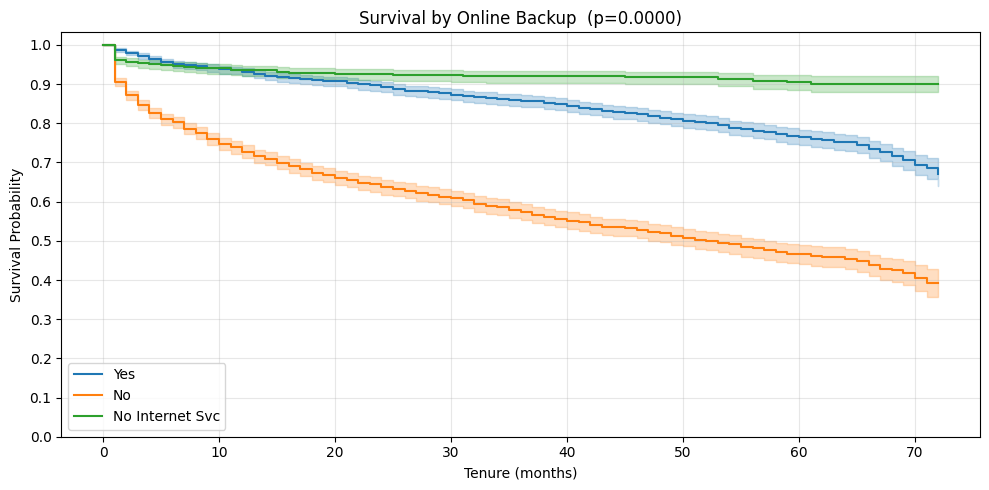

Multivariate Log-Rank p-value: 0.0000  →  ✅ Significant


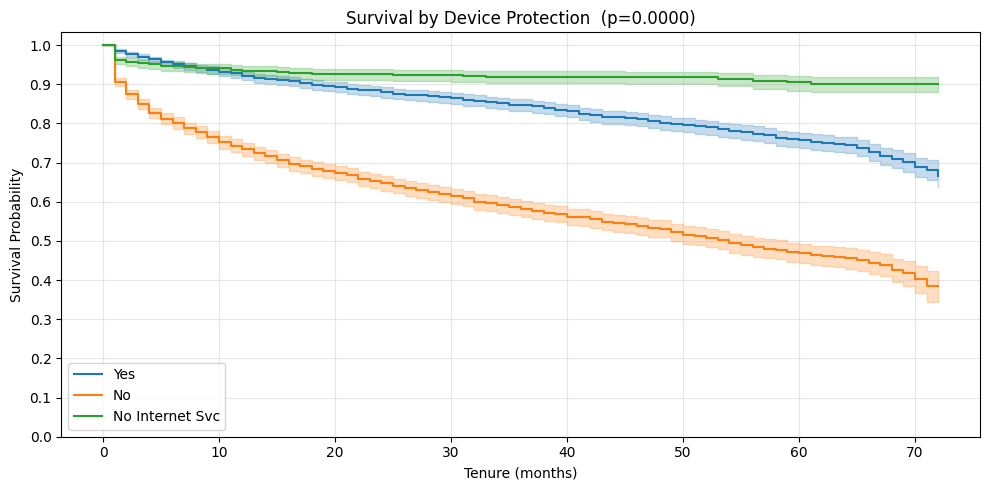

Multivariate Log-Rank p-value: 0.0000  →  ✅ Significant


In [44]:
for col, title in [("OnlineSecurity", "Online Security"), ("TechSupport", "Tech Support"),
                   ("OnlineBackup", "Online Backup"), ("DeviceProtection", "Device Protection")]:
    plot_km_multi_groups(
        {
            "Yes":               df[col] == "Yes",
            "No":                df[col] == "No",
            "No Internet Svc":   df[col] == "No internet service",
        },
        f"Survival by {title}", col
    )

### 4.9 Log-Rank Test Summary

| Feature | Significant? | Insight |
|---|---|---|
| Gender | ❌ No | Gender doesn't affect churn |
| Senior Citizen | ✅ Yes | Seniors churn faster |
| Partner | ✅ Yes | Customers with partners churn less |
| Dependents | ✅ Yes | Customers with dependents churn less |
| Internet Service | ✅ Yes | Fiber Optic users churn most |
| Contract Type | ✅ Yes | Month-to-month = highest risk |
| Paperless Billing | ✅ Yes | Paperless billing customers churn more |
| Payment Method | ✅ Yes | Electronic check = highest risk |

## 5. Cox Proportional Hazards Regression

The Cox model estimates the **hazard ratio** for each feature:

$$h(t|X) = h_0(t) \cdot \exp(\beta_1 X_1 + \beta_2 X_2 + \ldots)$$

- h₀(t) = baseline hazard
- exp(βᵢ) > 1 → feature **increases** churn risk
- exp(βᵢ) < 1 → feature **decreases** churn risk

In [45]:
def prepare_cox_data(df: pd.DataFrame) -> pd.DataFrame:
    """
    Encodes all features for CoxPH model.
    
    FIX: original used statsmodels.add_constant() which is not needed for lifelines CoxPH.
    FIX: original dropped tenure and Churn BEFORE fitting — lifelines needs them as columns.
    FIX: original applied get_dummies on ALL columns including already-encoded ones.
    """
    d = df.copy()
    
    # Fix TotalCharges (already done above, but safe to repeat)
    d["TotalCharges"] = pd.to_numeric(d["TotalCharges"], errors="coerce").fillna(0)
    
    # Drop non-informative column
    d.drop(["customerID"], axis=1, inplace=True, errors="ignore")
    
    # Binary columns
    for col in ["Partner", "Dependents", "PaperlessBilling", "PhoneService"]:
        d[col] = (d[col] == "Yes").astype(int)
    
    d["gender"] = (d["gender"] == "Female").astype(int)
    d["MultipleLines"] = d["MultipleLines"].map({"No phone service": 0, "No": 0, "Yes": 1})
    
    for col in ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                "TechSupport", "StreamingTV", "StreamingMovies"]:
        d[col] = d[col].map({"No internet service": 0, "No": 0, "Yes": 1})
    
    # One-hot encode remaining categoricals (drop_first to avoid multicollinearity)
    d = pd.get_dummies(d, columns=["InternetService", "Contract", "PaymentMethod"],
                       drop_first=True)
    d = d.astype({c: int for c in d.select_dtypes("bool").columns})
    
    # lifelines CoxPH needs duration + event in the same DataFrame
    # FIX: original dropped tenure and Churn before passing to cph.fit() — that breaks the fit
    return d

cox_df = prepare_cox_data(df)
print(f"Cox DataFrame shape: {cox_df.shape}")
cox_df.head()

Cox DataFrame shape: (7043, 24)


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,0,0,0,0,1,0
1,0,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,0,0,1,0,0,0,1
2,0,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,0,0,0,0,1
3,0,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,0,0,1,0,0,0,0
4,1,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,1,0,0,0,0,1,0


In [46]:
cph = CoxPHFitter(penalizer=0.1)   # FIX: added L2 penalizer to improve stability on correlated features
cph.fit(cox_df, duration_col="tenure", event_col="Churn")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 7043 total observations, 5174 right-censored observations>
             duration col = 'tenure'
                event col = 'Churn'
                penalizer = 0.1
                 l1 ratio = 0.0
      baseline estimation = breslow
   number of observations = 7043
number of events observed = 1869
   partial log-likelihood = -13988.77
         time fit was run = 2026-03-09 23:57:26 UTC

---
                                       coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                              
gender                                 0.03      1.03      0.04           -0.04            0.11                0.96                1.12
SeniorCitizen                          0.06      1.06      0.05           -0.04            0.15                0.96                1.17
Partner                               -0.32      0.73      0.04           -0.40           -0.24                0.67                0.79
Dependents                            -0.17      0.84      0.05           -0.27           -0.07                0.76                0.93
PhoneService                           0.03      1.03      0.08           -0.12            0.18                0.89                1.20
MultipleLines                         -0.16      0.85      0.04           -0.24           -0.07                0.78                0.93
OnlineSecurity                        -0.37      0.69      0.05           -0.47           -0.27                0.63                0.76
OnlineBackup                          -0.28      0.75      0.04           -0.37           -0.19                0.69                0.82
DeviceProtection                      -0.16      0.85      0.05           -0.25           -0.07                0.78                0.93
TechSupport                           -0.29      0.75      0.05           -0.39           -0.19                0.68                0.83
StreamingTV                            0.04      1.04      0.05           -0.05            0.12                0.95                1.13
StreamingMovies                        0.01      1.01      0.05           -0.08            0.10                0.93                1.11
PaperlessBilling                       0.21      1.24      0.05            0.13            0.30                1.13                1.35
MonthlyCharges                         0.01      1.01      0.00            0.00            0.01                1.00                1.01
TotalCharges                          -0.00      1.00      0.00           -0.00           -0.00                1.00                1.00
InternetService_Fiber optic            0.52      1.69      0.05            0.42            0.63                1.52                1.87
InternetService_No                    -0.76      0.47      0.07           -0.90           -0.63                0.41                0.53
Contract_One year                     -0.71      0.49      0.06           -0.82           -0.59                0.44                0.55
Contract_Two year                     -1.16      0.31      0.07           -1.29           -1.04                0.27                0.35
PaymentMethod_Credit card (automatic) -0.19      0.82      0.06           -0.31           -0.08                0.73                0.92
PaymentMethod_Electronic check         0.41      1.50      0.05            0.31            0.50                1.37                1.65
PaymentMethod_Mailed check             0.21      1.23      0.06            0.09            0.32                1.10                1.38

                                       cmp to      z      p  -log2(p)
covariate                                                            
gender                                   0.00   0.84   0.40      1.31
SeniorCitizen                            0.00   1.15   0.25      2.01
Partner                   


Concordance Index (C-stat): 0.9038
(>0.7 is good; ~0.5 is random)


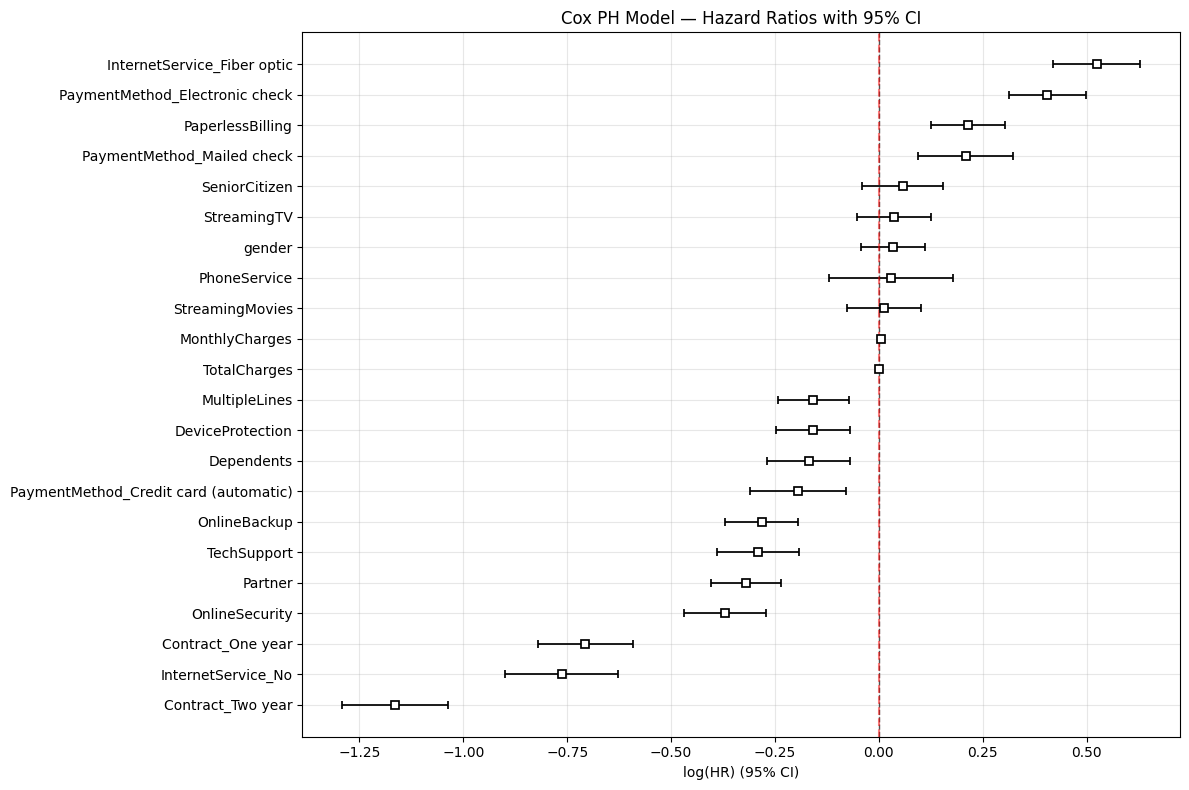

In [47]:
print(f"\nConcordance Index (C-stat): {cph.concordance_index_:.4f}")
print("(>0.7 is good; ~0.5 is random)")

fig, ax = plt.subplots(figsize=(12, 8))
cph.plot(ax=ax)
ax.set_title("Cox PH Model — Hazard Ratios with 95% CI")
ax.axvline(0, color="red", linestyle="--", alpha=0.5, label="HR=1 (no effect)")
plt.tight_layout()
plt.show()

### Interpreting Hazard Ratios
- **HR > 0** (right of red line) = feature **increases** churn risk
- **HR < 0** (left of red line) = feature **decreases** churn risk
- Width of CI = uncertainty; if CI crosses 0, effect is not significant

## 6. Individual Customer Survival & Hazard Curves

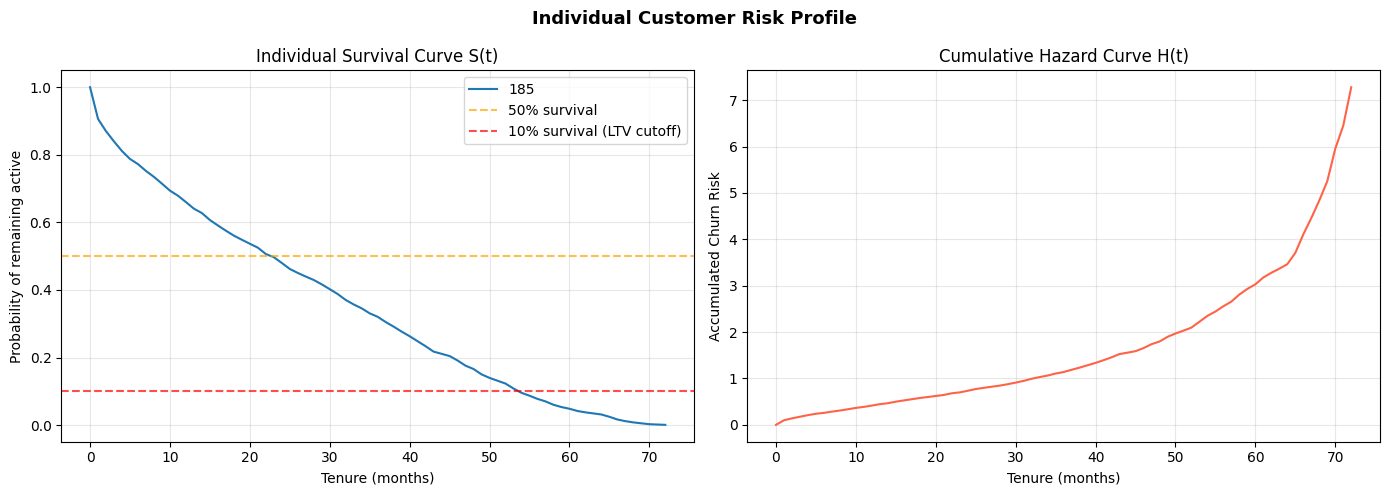

In [48]:
# Sample a random customer for demonstration
np.random.seed(42)
sample_customer = cox_df.drop(columns=["Churn"]).sample(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Survival curve
surv = cph.predict_survival_function(sample_customer)
surv.plot(ax=axes[0], legend=False)
axes[0].set_title("Individual Survival Curve S(t)")
axes[0].set_xlabel("Tenure (months)")
axes[0].set_ylabel("Probability of remaining active")
axes[0].axhline(0.5, color="orange", linestyle="--", alpha=0.7, label="50% survival")
axes[0].axhline(0.1, color="red",    linestyle="--", alpha=0.7, label="10% survival (LTV cutoff)")
axes[0].legend()

# Hazard curve
haz = cph.predict_cumulative_hazard(sample_customer)
haz.plot(ax=axes[1], legend=False, color="tomato")
axes[1].set_title("Cumulative Hazard Curve H(t)")
axes[1].set_xlabel("Tenure (months)")
axes[1].set_ylabel("Accumulated Churn Risk")

plt.suptitle("Individual Customer Risk Profile", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7. Customer Lifetime Value (LTV)

**Formula:**

$$\text{LTV} = \text{MonthlyCharges} \times \text{Expected Lifetime}$$

Where *Expected Lifetime* = the last month the survival probability is still > 10%.

In [49]:
def calculate_ltv(customer_row: pd.DataFrame, cph_model: CoxPHFitter, threshold: float = 0.1) -> dict:
    """
    Calculates Customer Lifetime Value using the Cox survival function.
    
    FIX: original used .reset_index() and manually renamed columns — fragile approach.
         Now uses pandas Series indexing directly.
    FIX: original didn't handle the case where survival never drops below threshold
         (very loyal customers) — added fallback to max observed tenure.
    
    Args:
        customer_row: Single-row DataFrame with customer features (no Churn column)
        cph_model: Fitted CoxPHFitter
        threshold: Survival probability below which customer is considered churned (default 10%)
    
    Returns:
        Dict with expected_lifetime_months and ltv_dollars
    """
    features = customer_row.drop(columns=["Churn"], errors="ignore")
    monthly_charges = df.loc[customer_row.index[0], "MonthlyCharges"]
    
    surv_func = cph_model.predict_survival_function(features).squeeze()
    
    # Expected lifetime = last time point where survival > threshold
    above_threshold = surv_func[surv_func > threshold]
    
    if len(above_threshold) > 0:
        expected_life = above_threshold.index.max()
    else:
        expected_life = surv_func.index.min()  # Customer is already high risk
    
    ltv = expected_life * monthly_charges
    
    return {
        "expected_lifetime_months": round(float(expected_life), 1),
        "monthly_charges": round(float(monthly_charges), 2),
        "ltv_dollars": round(float(ltv), 2),
    }


# Demo on sample customer
result = calculate_ltv(sample_customer, cph)
print("=" * 40)
print("  Customer Lifetime Value Report")
print("=" * 40)
for k, v in result.items():
    print(f"  {k:<28} {v}")
print("=" * 40)

  Customer Lifetime Value Report
  expected_lifetime_months     53.0
  monthly_charges              24.8
  ltv_dollars                  1314.4


Calculating LTV for all customers...


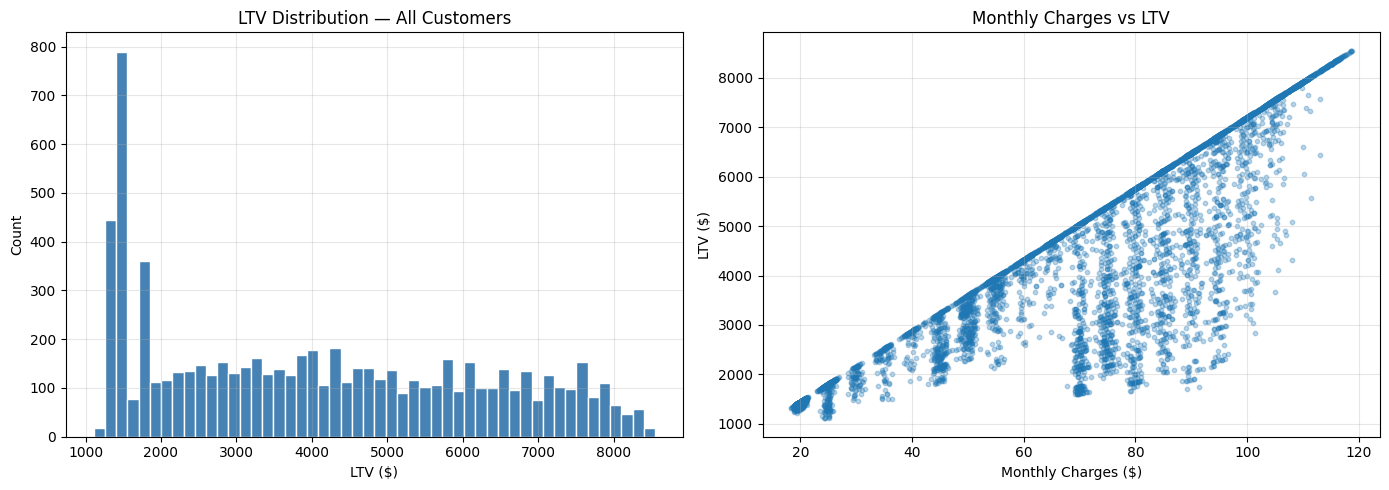


LTV Statistics:
count    7043.00
mean     4069.53
std      2138.10
min      1108.80
25%      1910.18
50%      3873.60
75%      5850.00
max      8550.00


In [50]:
# LTV distribution across all customers
print("Calculating LTV for all customers...")

ltv_records = []
for idx in cox_df.index:
    row = cox_df.loc[[idx]]
    try:
        ltv_records.append(calculate_ltv(row, cph))
    except Exception:
        pass

ltv_df = pd.DataFrame(ltv_records)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ltv_df["ltv_dollars"].hist(bins=50, ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("LTV Distribution — All Customers")
axes[0].set_xlabel("LTV ($)")
axes[0].set_ylabel("Count")

axes[1].scatter(ltv_df["monthly_charges"], ltv_df["ltv_dollars"], alpha=0.3, s=10)
axes[1].set_title("Monthly Charges vs LTV")
axes[1].set_xlabel("Monthly Charges ($)")
axes[1].set_ylabel("LTV ($)")

plt.tight_layout()
plt.show()

print(f"\nLTV Statistics:")
print(ltv_df["ltv_dollars"].describe().round(2).to_string())

## 8. Key Business Insights

| Finding | Action |
|---|---|
| Month-to-month customers churn 3× faster | Offer discounts to upgrade to annual contracts |
| Fiber Optic users churn more despite higher spend | Improve service quality or reduce pricing |
| Customers without Online Security/Tech Support churn more | Bundle these services for new customers |
| Electronic check users churn more | Incentivise switching to automatic payment |
| Senior citizens have lower survival probability | Create dedicated retention programs for seniors |
| Early tenure (0–12 months) is the highest risk period | Focus onboarding experience and early engagement |

### Model Performance
- **Concordance Index** measures how well the Cox model ranks customer risk
- C-stat > 0.70 means the model correctly ranks 70%+ of customer pairs by churn risk
- Use this model alongside the ML classifier for a complete churn prevention strategy

## 9. Save the Cox Model

In [51]:
import pickle, os

os.makedirs("final_model", exist_ok=True)

with open("final_model/survival_model.pkl", "wb") as f:
    pickle.dump(cph, f)

print("✓ Cox PH model saved to final_model/survival_model.pkl")

# Quick reload test
with open("final_model/survival_model.pkl", "rb") as f:
    cph_loaded = pickle.load(f)
print(f"✓ Reload test passed — C-stat: {cph_loaded.concordance_index_:.4f}")

✓ Cox PH model saved to final_model/survival_model.pkl
✓ Reload test passed — C-stat: 0.9038
